<a href="https://colab.research.google.com/github/nibaskumar93n-debug/Morphoinformatics/blob/main/Heavy_Metals_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Heavy Metals Soil Analysis — Complete Pipeline
### Corrected version — All bugs fixed

**Key fix:** ADD formulas now include the mandatory conversion factor **CF = 10⁻⁶ kg/mg**.
Without it, HI was ~500,000 (should be ~0.3–5) and CR was ~68 (should be ~10⁻⁴).

| Cell | What was wrong | Fix |
|------|---------------|-----|
| 14 | Missing `× 1e-6` in ADD_ing and ADD_der | Added `CF = 1e-6` |
| 15 | HI inflated by ×10⁶ | Fixed via Cell 14 |
| 16 | LADD_ing and LADD_der missing `× 1e-6` | Added `CF = 1e-6` |
| 8  | seaborn FutureWarning | Used `hue=` + `legend=False` |

In [1]:
# ── CELL 1: Install packages ──────────────────────────────────────────────────
!pip install -q pandas numpy matplotlib scipy seaborn openpyxl
print('✅ All packages installed!')

✅ All packages installed!


In [2]:
# ── CELL 2: Upload and load your Excel file ───────────────────────────────────
from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

print(f'✅ File loaded: {filename}')
print(f'   Shape: {df.shape}')
print(f'   Columns: {df.columns.tolist()}')
print(df.head())

Saving Health Risk Analysis (1).xlsx to Health Risk Analysis (1).xlsx
✅ File loaded: Health Risk Analysis (1).xlsx
   Shape: (40, 14)
   Columns: ['sample', 'Latitude ', 'Longitude', 'Ni', 'V', 'Co', 'Cd', 'Fe', 'Mn', 'As', 'Zn', ' Pb', 'Cr', 'Cu']
  sample   Latitude    Longitude    Ni     V    Co        Cd        Fe  \
0  ASA-1  22°31'22"N  89°09'14"E  32.1  63.8  51.4  0.170000  27946.15   
1  ASA-2  22°30'38"N  89°09'20"E  38.1  68.8  58.4  1.856698  32341.50   
2  ASA-3  22°30'18"N  89°09'29"E  38.9  73.8  61.1  1.000000  33942.60   
3  ASA-4  22°29'50"N  89°09'20"E  36.5  63.8  55.6  0.060000  28941.75   
4  ASA-5  22°29'23"N  89°09'35"E  36.5  68.8  57.0  1.868774  34847.50   

           Mn        As         Zn         Pb          Cr    Cu  
0  596.548125  7.902725  84.850000  30.000000  121.113281  51.7  
1  638.338235  7.202664  66.887868  37.443623  149.509688  59.1  
2  492.063158  7.325786  77.447368  45.091421  179.843906  58.3  
3  619.801875  7.873208  72.493750  31.396

In [3]:
# ── CELL 3: Clean columns, set sample column, and extract metals ─────────────
import numpy as np

df.columns = df.columns.str.strip()
df = df.rename(columns={'sample': 'Sample'})
metals = ['Ni', 'V', 'Co', 'Cd', 'Fe', 'Mn', 'As', 'Zn', 'Pb', 'Cr', 'Cu']

missing = [m for m in metals if m not in df.columns]
if missing:
    print(f'⚠️ Missing columns: {missing}')

df['Zone'] = df['Sample'].apply(
    lambda x: 'ASA' if str(x).startswith('ASA') else
              'ND'  if str(x).startswith('ND')  else 'DUM'
)

for m in metals:
    if m in df.columns:
        df[m] = pd.to_numeric(df[m], errors='coerce')

print(f'✅ Metals: {metals}')
print(f'   Zones: {df["Zone"].value_counts().to_dict()}')
print(df[['Sample', 'Zone'] + metals].head(5).to_string(index=False))

✅ Metals: ['Ni', 'V', 'Co', 'Cd', 'Fe', 'Mn', 'As', 'Zn', 'Pb', 'Cr', 'Cu']
   Zones: {'ASA': 20, 'ND': 10, 'DUM': 10}
Sample Zone   Ni    V   Co       Cd       Fe         Mn       As        Zn        Pb         Cr   Cu
 ASA-1  ASA 32.1 63.8 51.4 0.170000 27946.15 596.548125 7.902725 84.850000 30.000000 121.113281 51.7
 ASA-2  ASA 38.1 68.8 58.4 1.856698 32341.50 638.338235 7.202664 66.887868 37.443623 149.509688 59.1
 ASA-3  ASA 38.9 73.8 61.1 1.000000 33942.60 492.063158 7.325786 77.447368 45.091421 179.843906 58.3
 ASA-4  ASA 36.5 63.8 55.6 0.060000 28941.75 619.801875 7.873208 72.493750 31.396226 125.585156 57.3
 ASA-5  ASA 36.5 68.8 57.0 1.868774 34847.50 644.476103 7.647799 81.590074 37.826818 150.987891 55.5


In [4]:
# ── CELL 4: Background values and guidelines ──────────────────────────────────
background = {
    'Ni': 68,    'V': 130,  'Co': 19,   'Cd': 0.3,
    'Fe': 47200, 'Mn': 850, 'As': 13,   'Zn': 95,
    'Pb': 20,    'Cr': 90,  'Cu': 45
}

who_guideline = {
    'Ni': 35,    'V': 120,   'Co': 50,   'Cd': 3,
    'Fe': 50000, 'Mn': 500,  'As': 20,   'Zn': 200,
    'Pb': 85,    'Cr': 100,  'Cu': 63
}

print('✅ Background values (Turekian & Wedepohl 1961; As: Wedepohl 1995):')
for m in metals:
    print(f'   {m:4s}: background = {background[m]:<8} WHO = {who_guideline[m]}')

✅ Background values (Turekian & Wedepohl 1961; As: Wedepohl 1995):
   Ni  : background = 68       WHO = 35
   V   : background = 130      WHO = 120
   Co  : background = 19       WHO = 50
   Cd  : background = 0.3      WHO = 3
   Fe  : background = 47200    WHO = 50000
   Mn  : background = 850      WHO = 500
   As  : background = 13       WHO = 20
   Zn  : background = 95       WHO = 200
   Pb  : background = 20       WHO = 85
   Cr  : background = 90       WHO = 100
   Cu  : background = 45       WHO = 63


In [5]:
# ── CELL 5: Descriptive statistics ───────────────────────────────────────────
from scipy import stats

rows = []
for m in metals:
    v = df[m].dropna().values
    rows.append({
        'Metal'          : m,
        'n'              : len(v),
        'Min'            : round(v.min(), 3),
        'Max'            : round(v.max(), 3),
        'Mean'           : round(v.mean(), 3),
        'Median'         : round(np.median(v), 3),
        'Std'            : round(v.std(), 3),
        'CV(%)'          : round(v.std()/v.mean()*100, 2),
        'Skewness'       : round(stats.skew(v), 3),
        'Kurtosis'       : round(stats.kurtosis(v), 3),
        'Background'     : background[m],
        'Mean/Background': round(v.mean()/background[m], 3)
    })

stats_df = pd.DataFrame(rows)
print('✅ Descriptive statistics:')
print(stats_df.to_string(index=False))

stats_df.to_excel('descriptive_statistics.xlsx', index=False)
print('\n✅ Saved: descriptive_statistics.xlsx')

✅ Descriptive statistics:
Metal  n       Min       Max      Mean    Median      Std  CV(%)  Skewness  Kurtosis  Background  Mean/Background
   Ni 40    28.700    50.900    42.050    41.350    5.851  13.91    -0.129    -1.126        68.0            0.618
    V 40    63.800    90.800    78.425    79.800   10.428  13.30    -0.127    -1.632       130.0            0.603
   Co 40    45.700    69.100    58.958    58.850    6.003  10.18    -0.222    -0.610        19.0            3.103
   Cd 40     0.060     2.032     1.289     1.565    0.634  49.20    -0.682    -0.972         0.3            4.296
   Fe 40 22375.800 56664.600 38243.382 36854.750 8523.893  22.29     0.492    -0.485     47200.0            0.810
   Mn 40   375.324   934.920   638.282   629.351  135.123  21.17     0.222    -0.166       850.0            0.751
   As 40     5.491    11.721     8.071     7.888    1.393  17.26     0.228    -0.218        13.0            0.621
   Zn 40    50.433   105.769    75.308    72.637   13.902  18.

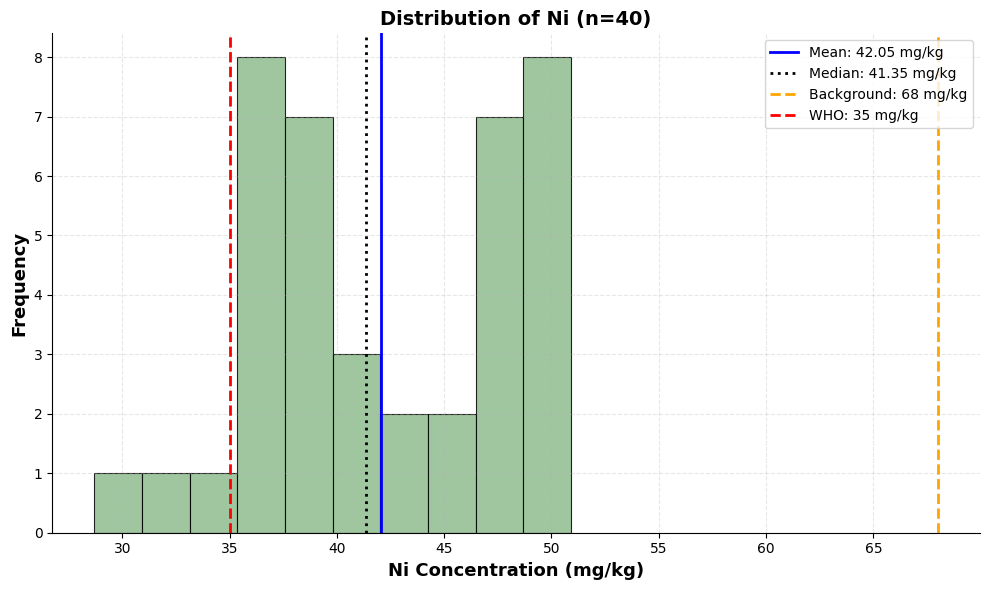

✅ Saved: distribution_Ni.svg


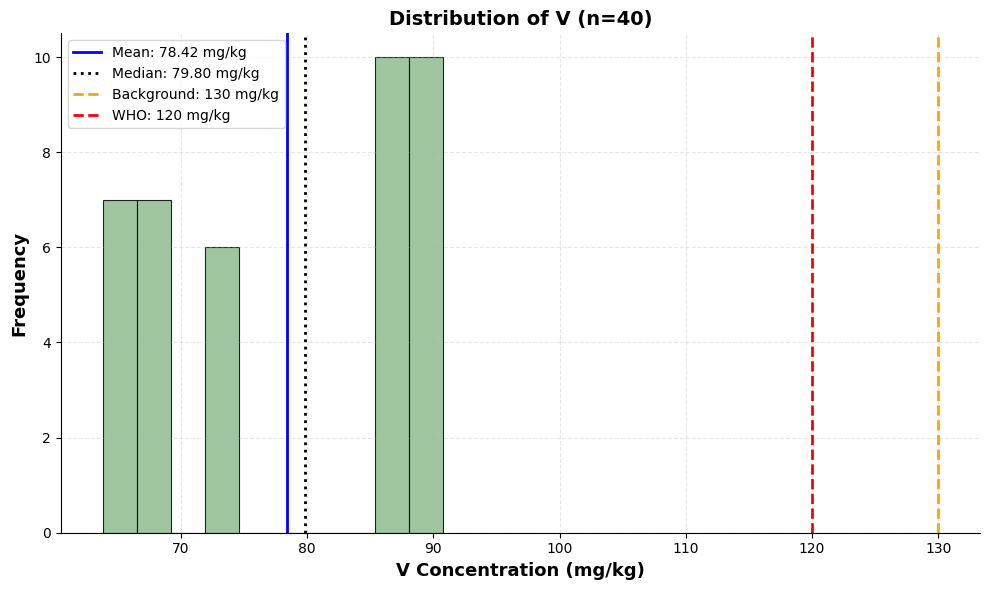

✅ Saved: distribution_V.svg


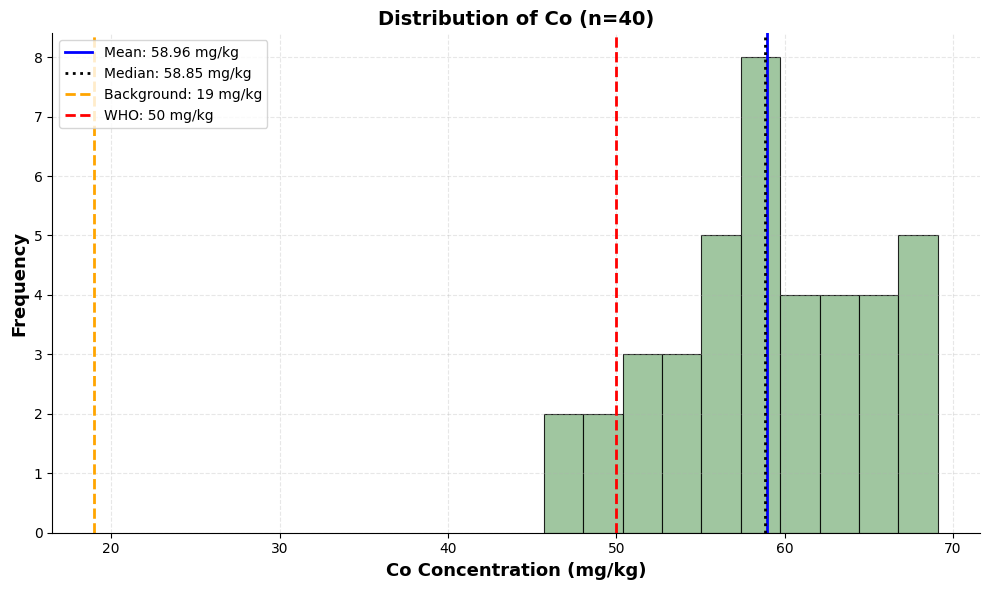

✅ Saved: distribution_Co.svg


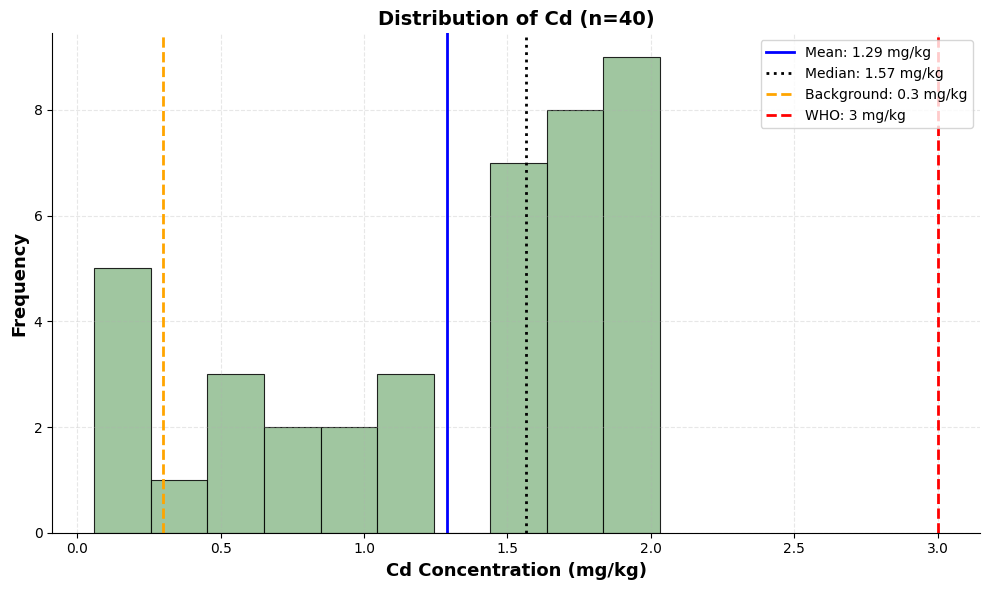

✅ Saved: distribution_Cd.svg


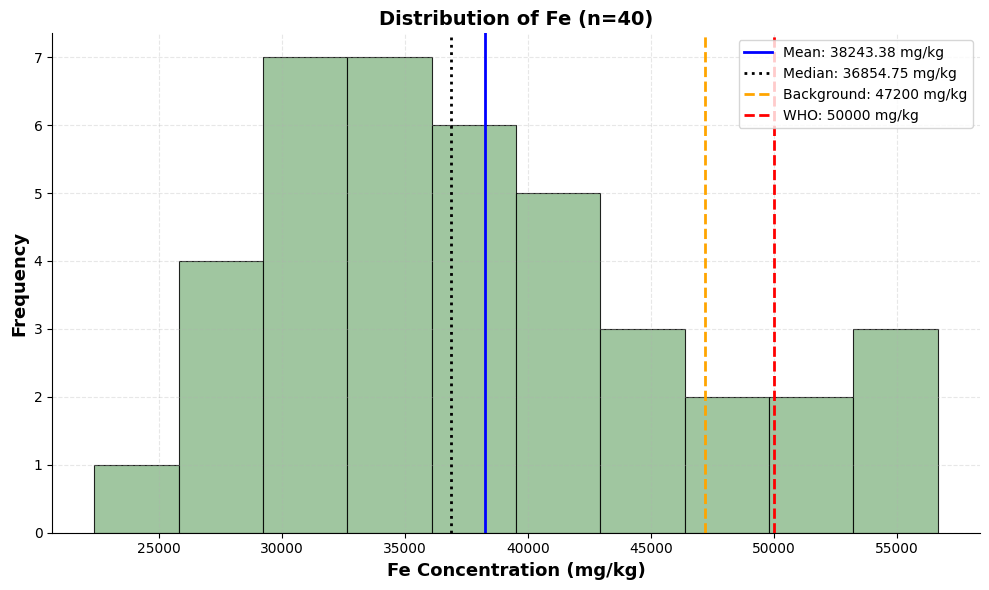

✅ Saved: distribution_Fe.svg


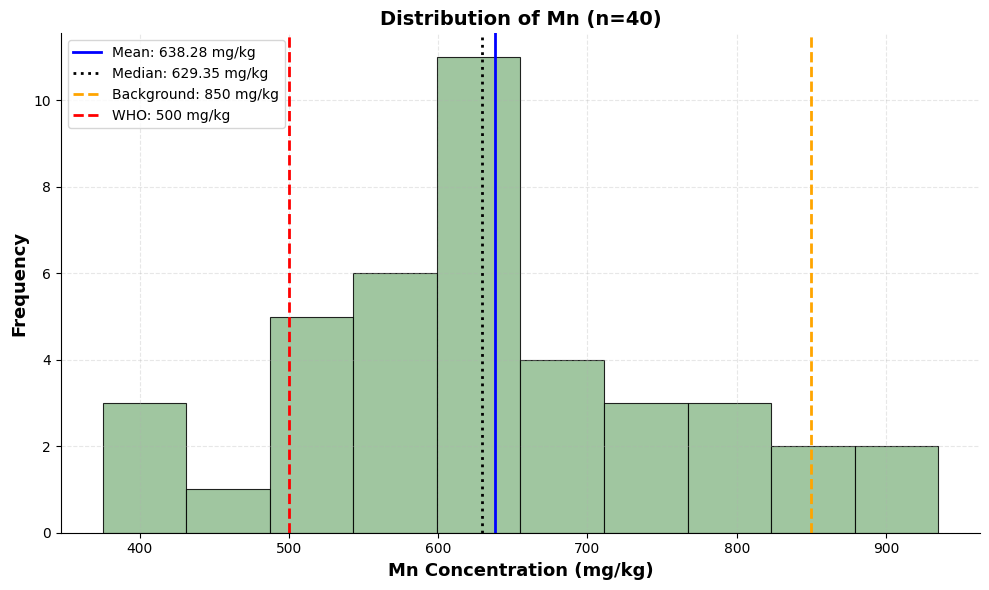

✅ Saved: distribution_Mn.svg


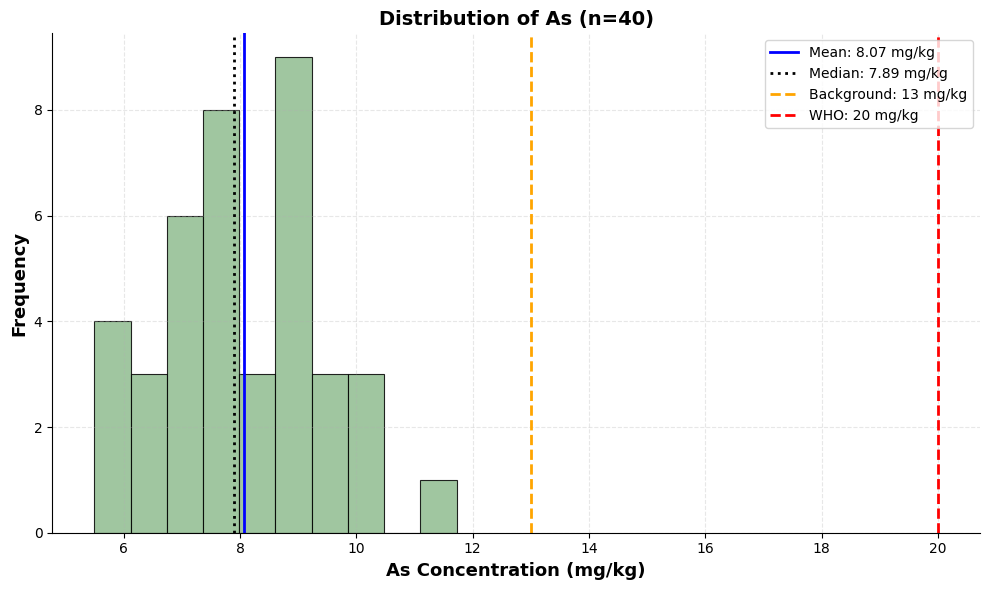

✅ Saved: distribution_As.svg


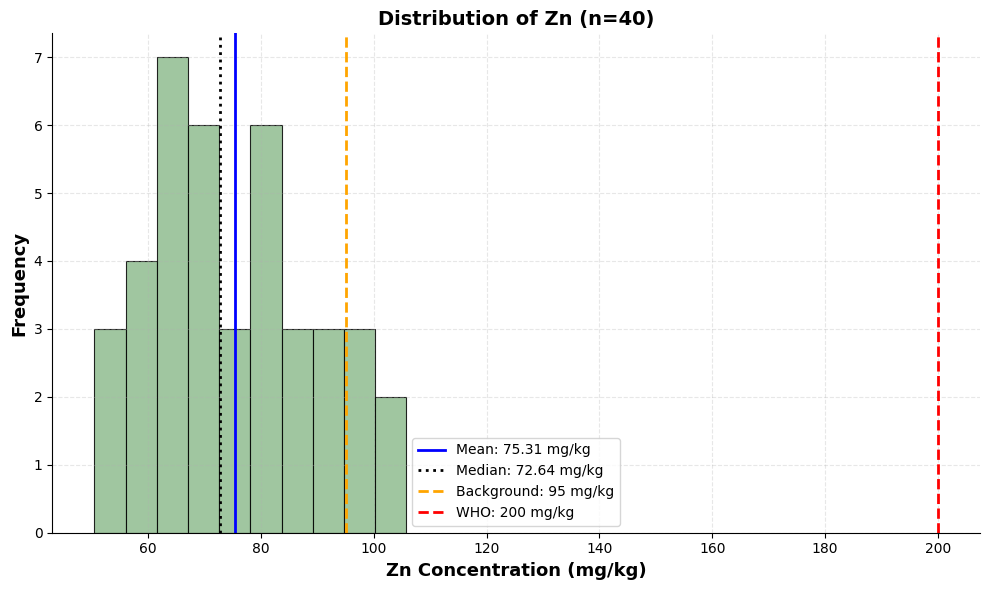

✅ Saved: distribution_Zn.svg


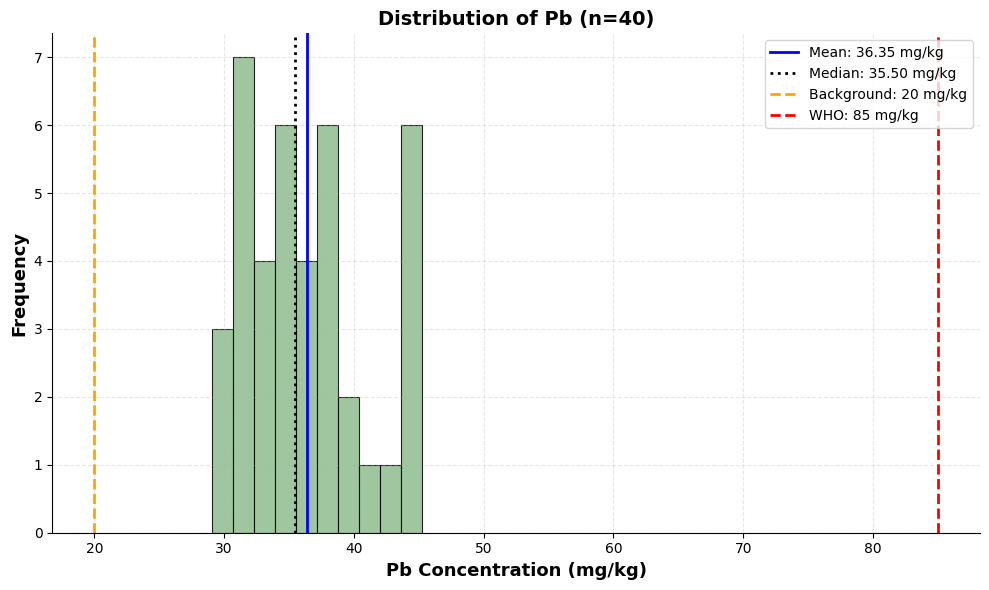

✅ Saved: distribution_Pb.svg


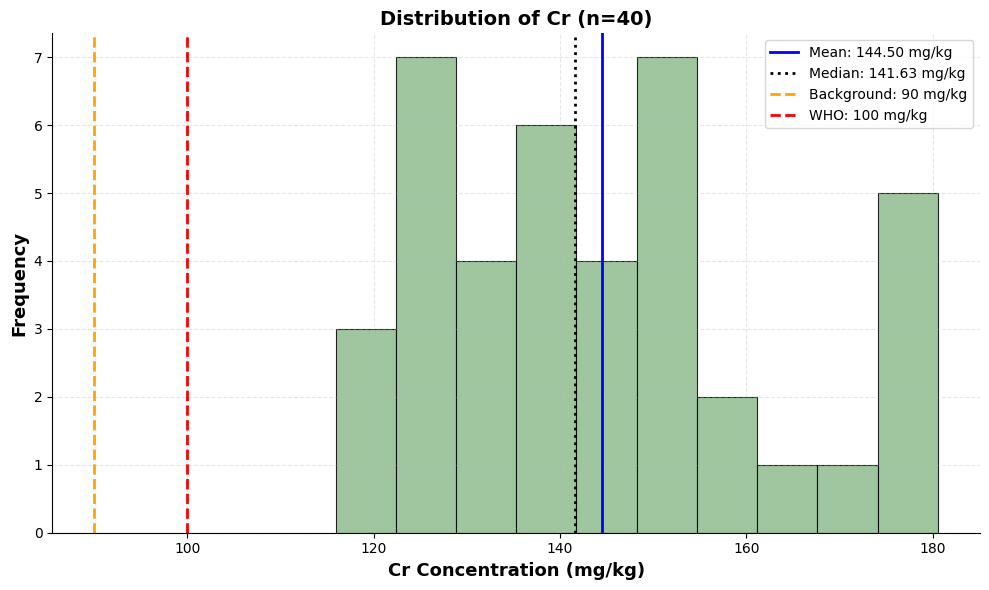

✅ Saved: distribution_Cr.svg


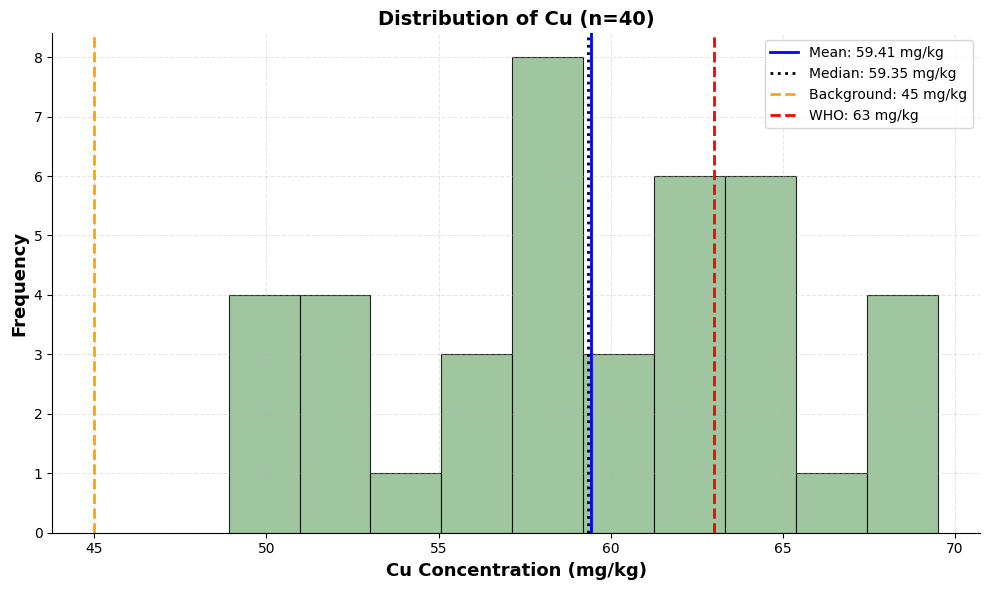

✅ Saved: distribution_Cu.svg


In [6]:
# ── CELL 6: Distribution histogram — linear scale ─────────────────────────────
import matplotlib.pyplot as plt

for m in metals:
    vals = df[m].dropna().values
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(vals, bins=10, color='#8FBC8F', edgecolor='black',
            linewidth=0.8, alpha=0.85)
    ax.axvline(np.mean(vals), color='blue',   lw=2, ls='-',
               label=f'Mean: {np.mean(vals):.2f} mg/kg')
    ax.axvline(np.median(vals), color='black', lw=2, ls=':',
               label=f'Median: {np.median(vals):.2f} mg/kg')
    ax.axvline(background[m], color='orange', lw=2, ls='--',
               label=f'Background: {background[m]} mg/kg')
    ax.axvline(who_guideline[m], color='red', lw=2, ls='--',
               label=f'WHO: {who_guideline[m]} mg/kg')
    ax.set_xlabel(f'{m} Concentration (mg/kg)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
    ax.set_title(f'Distribution of {m} (n={len(vals)})', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'distribution_{m}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: distribution_{m}.svg')

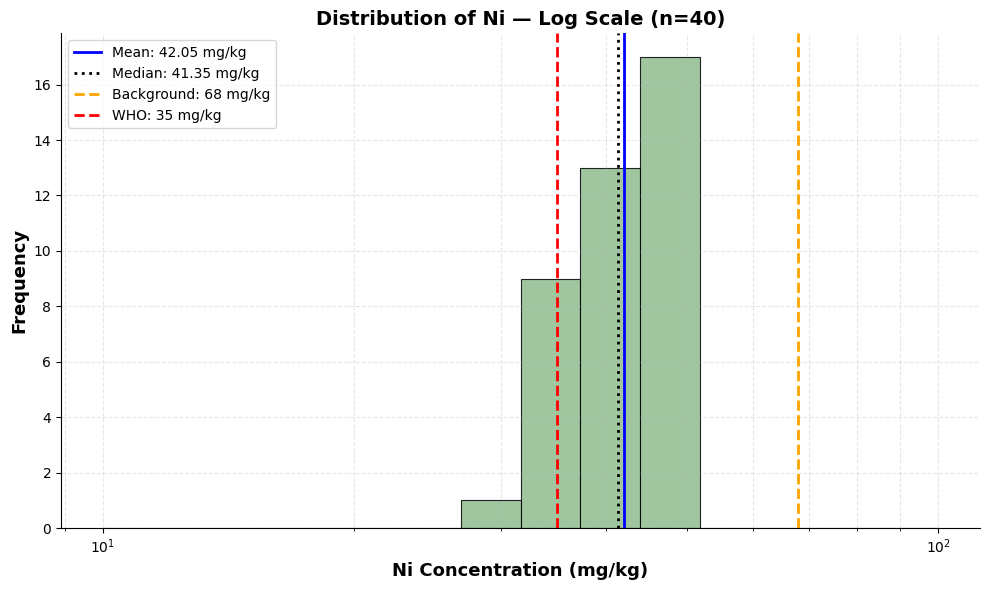

✅ Saved: distribution_log_Ni.svg


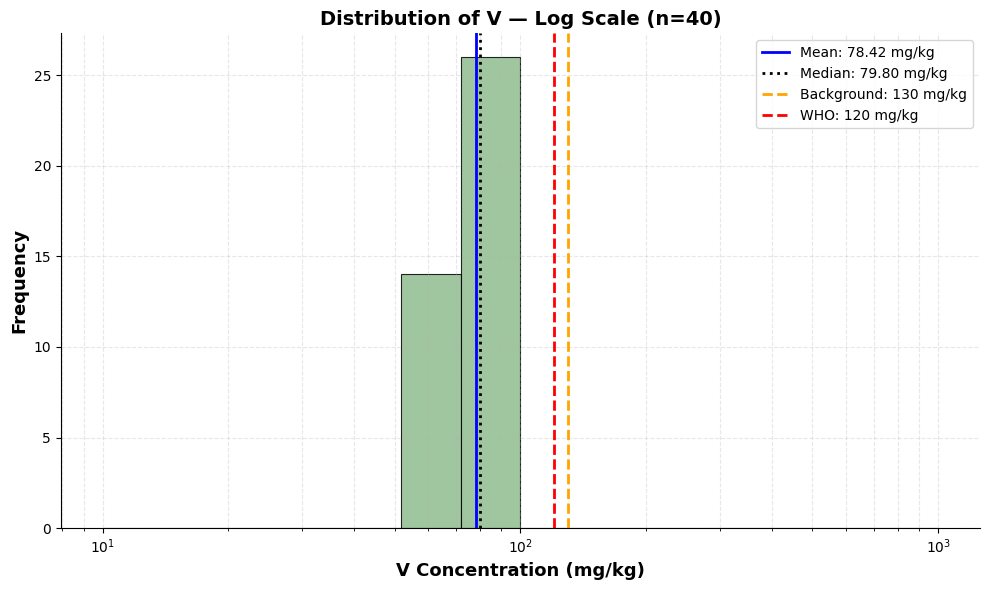

✅ Saved: distribution_log_V.svg


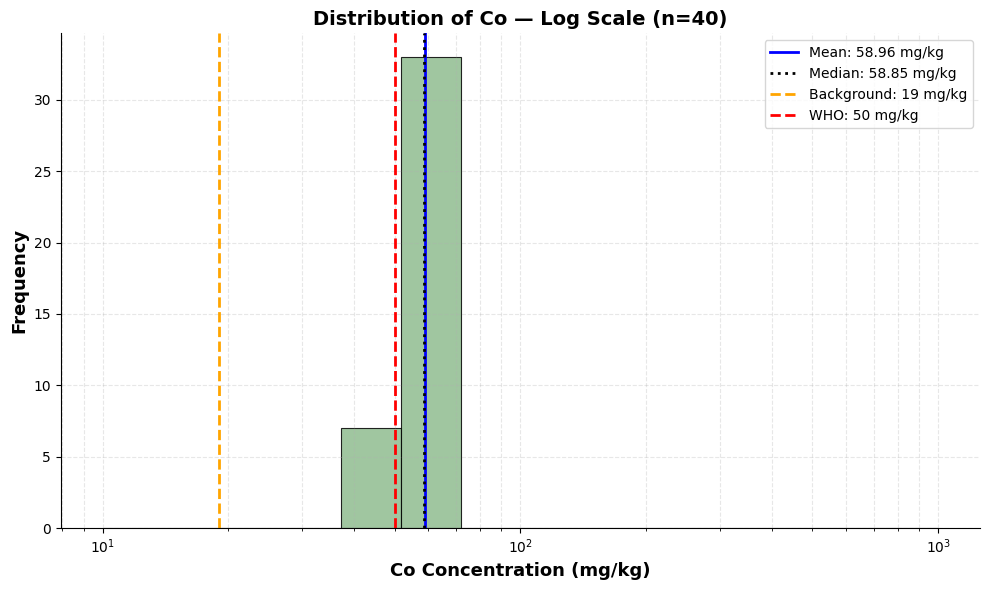

✅ Saved: distribution_log_Co.svg


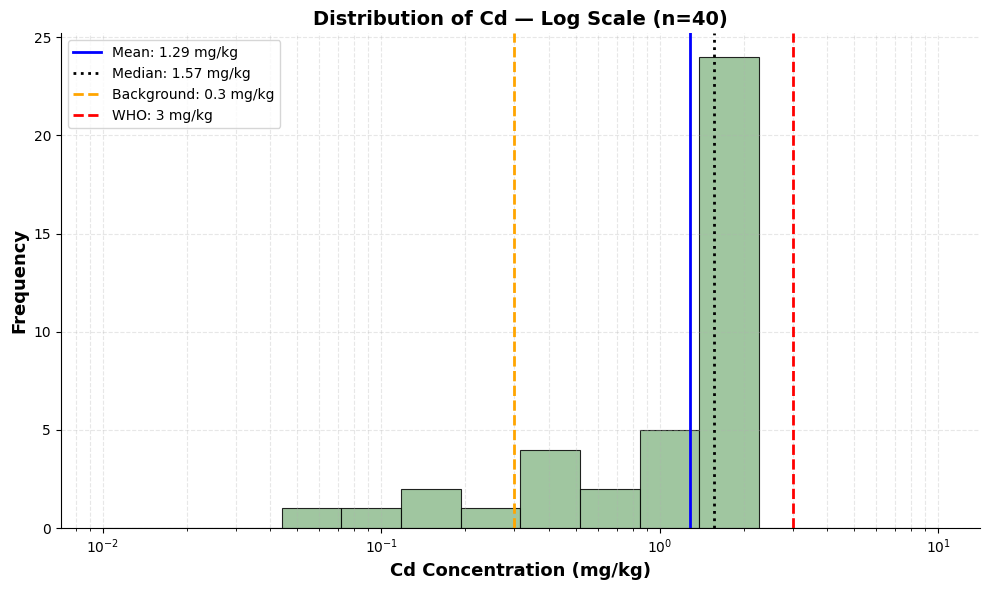

✅ Saved: distribution_log_Cd.svg


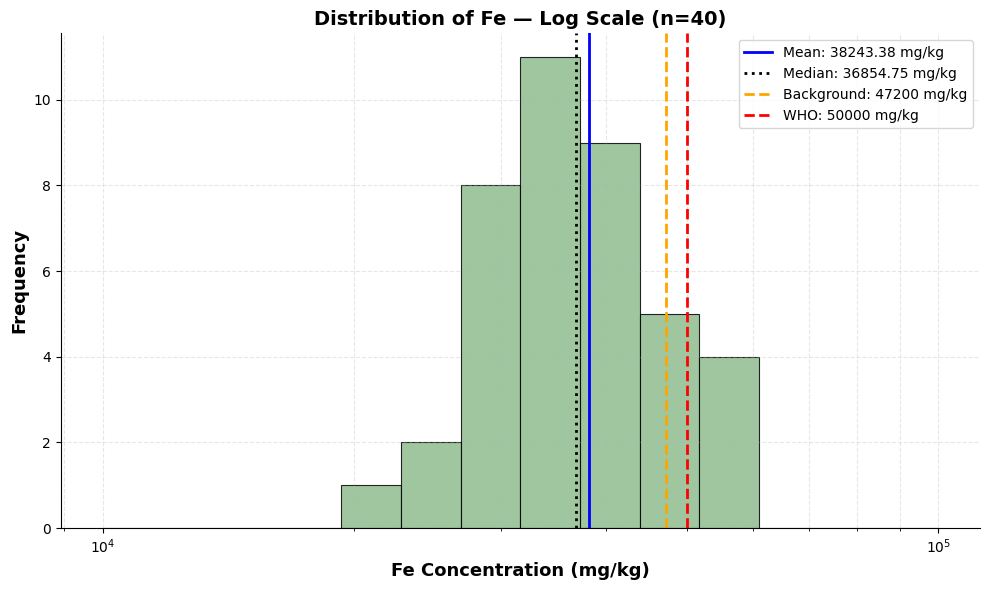

✅ Saved: distribution_log_Fe.svg


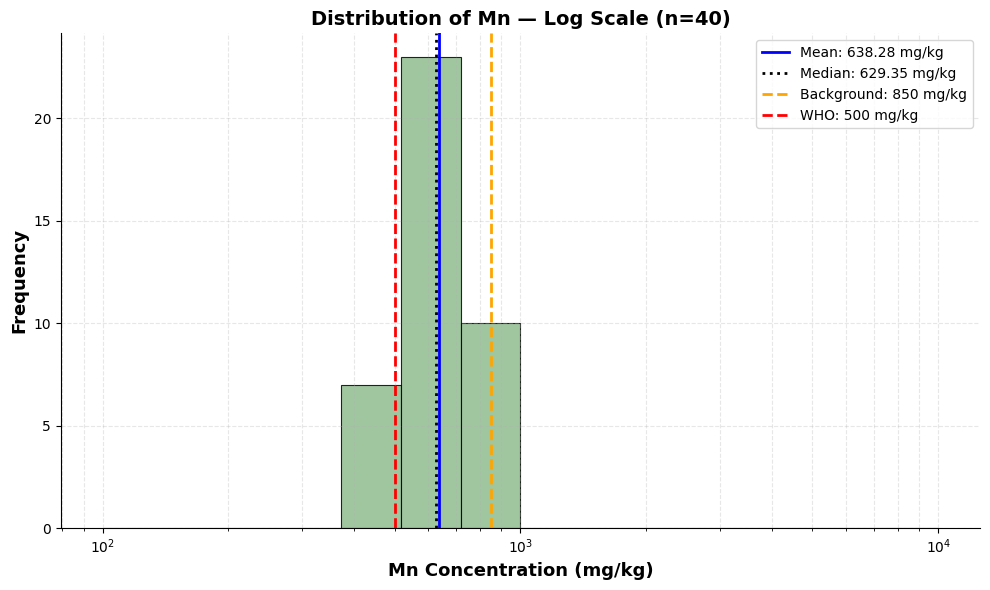

✅ Saved: distribution_log_Mn.svg


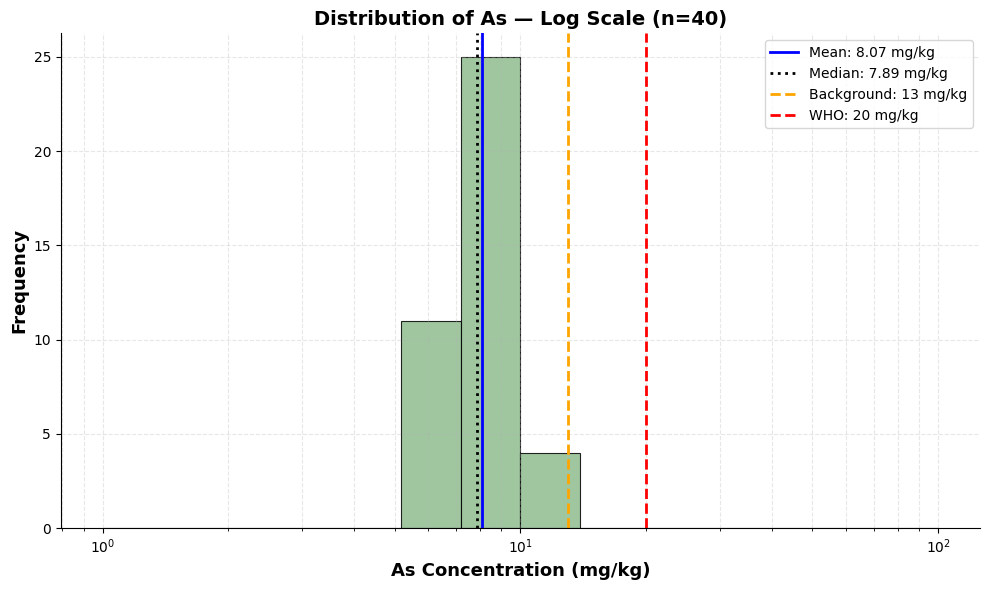

✅ Saved: distribution_log_As.svg


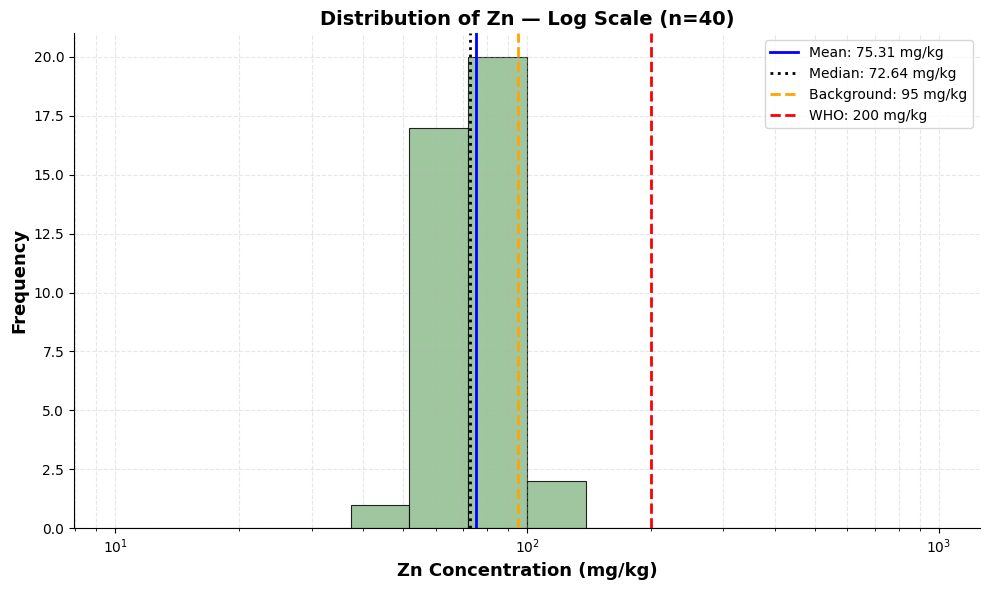

✅ Saved: distribution_log_Zn.svg


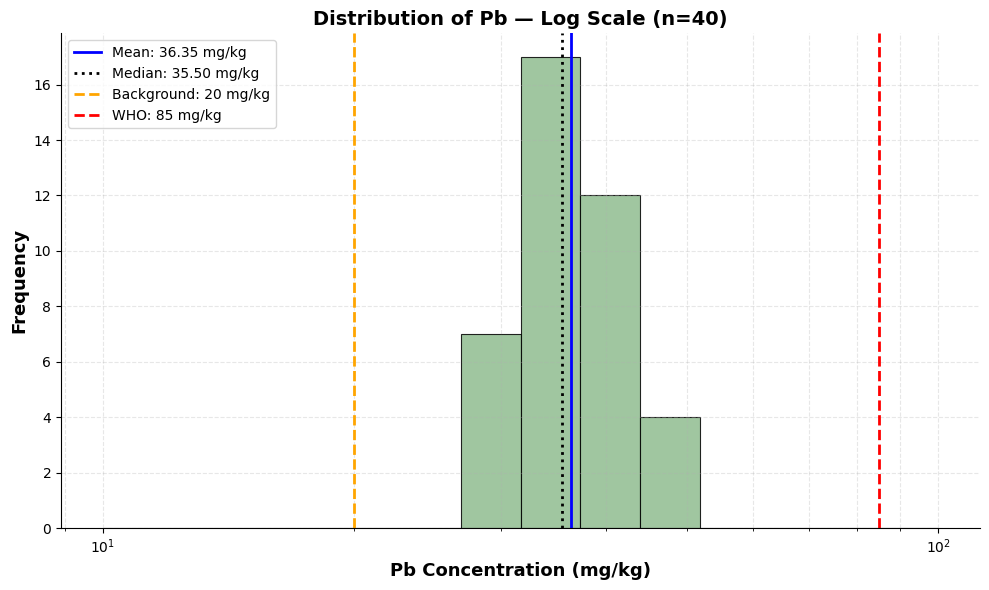

✅ Saved: distribution_log_Pb.svg


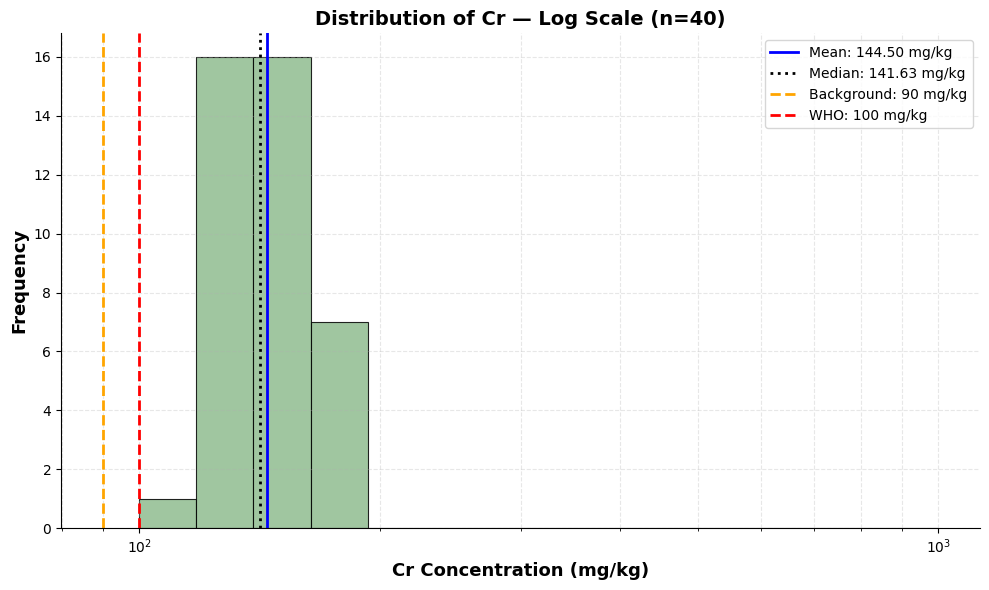

✅ Saved: distribution_log_Cr.svg


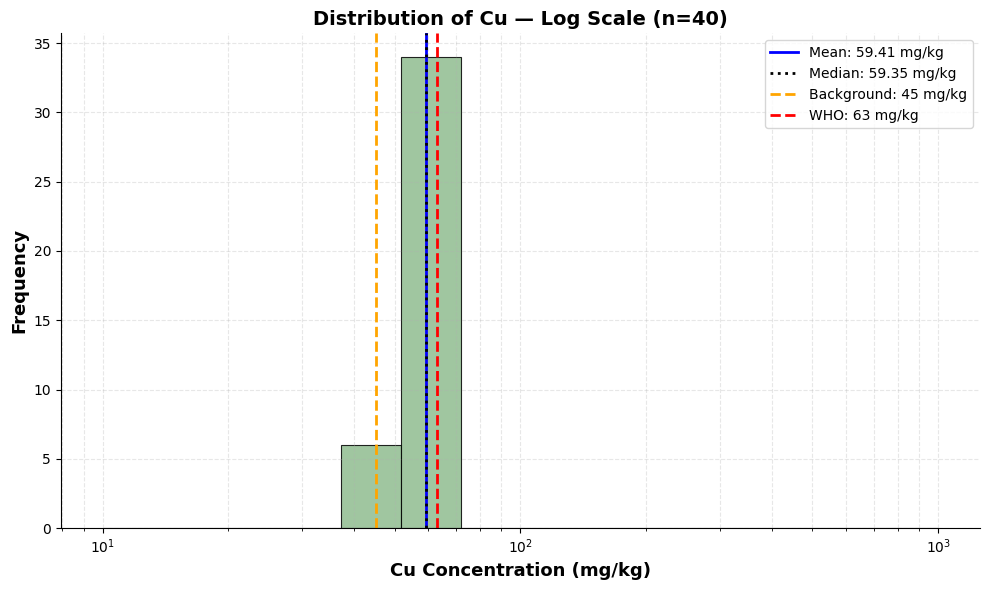

✅ Saved: distribution_log_Cu.svg


In [7]:
# ── CELL 7: Distribution histogram — log scale ───────────────────────────────
for m in metals:
    vals = df[m].dropna().values
    log_min = np.floor(np.log10(vals.min()))
    log_max = np.ceil(np.log10(vals.max() * 1.5))
    bins = np.logspace(log_min, log_max, 15)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(vals, bins=bins, color='#8FBC8F', edgecolor='black',
            linewidth=0.8, alpha=0.85)
    ax.axvline(np.mean(vals), color='blue',   lw=2, ls='-',
               label=f'Mean: {np.mean(vals):.2f} mg/kg')
    ax.axvline(np.median(vals), color='black', lw=2, ls=':',
               label=f'Median: {np.median(vals):.2f} mg/kg')
    ax.axvline(background[m], color='orange', lw=2, ls='--',
               label=f'Background: {background[m]} mg/kg')
    ax.axvline(who_guideline[m], color='red', lw=2, ls='--',
               label=f'WHO: {who_guideline[m]} mg/kg')
    ax.set_xscale('log')
    ax.set_xlabel(f'{m} Concentration (mg/kg)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
    ax.set_title(f'Distribution of {m} — Log Scale (n={len(vals)})',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(True, which='both', alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'distribution_log_{m}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: distribution_log_{m}.svg')

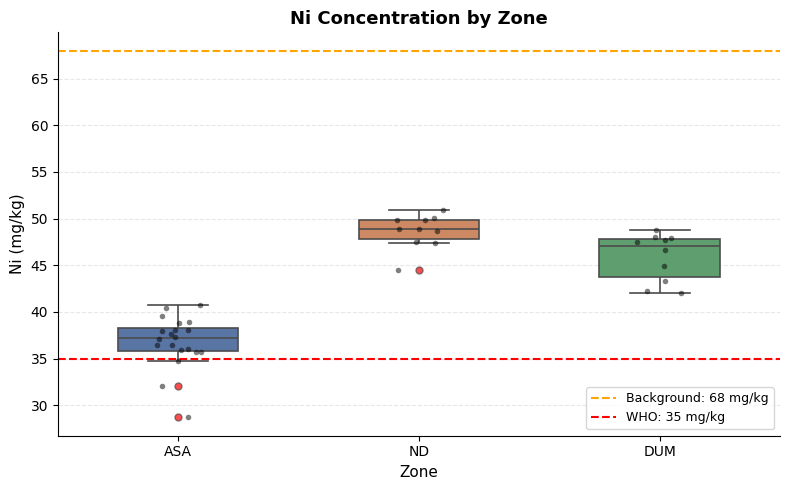

✅ Saved: boxplot_Ni.svg


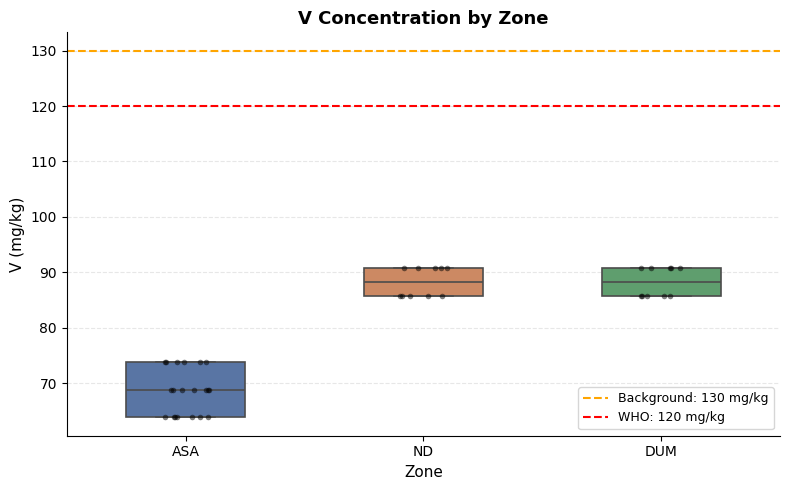

✅ Saved: boxplot_V.svg


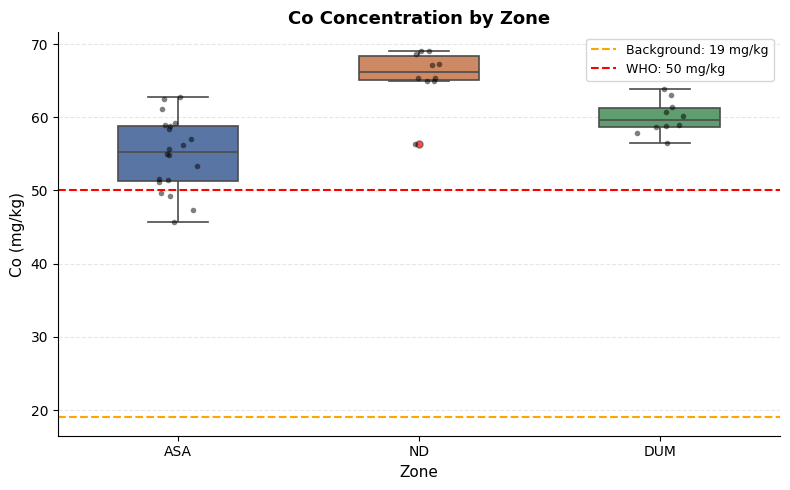

✅ Saved: boxplot_Co.svg


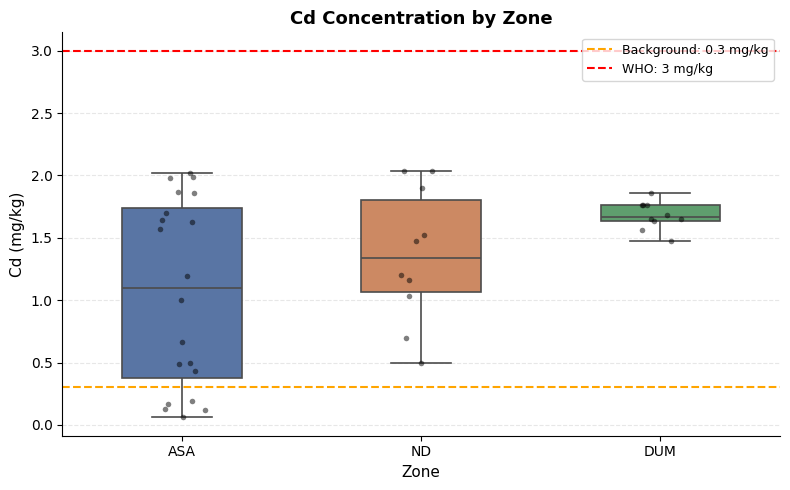

✅ Saved: boxplot_Cd.svg


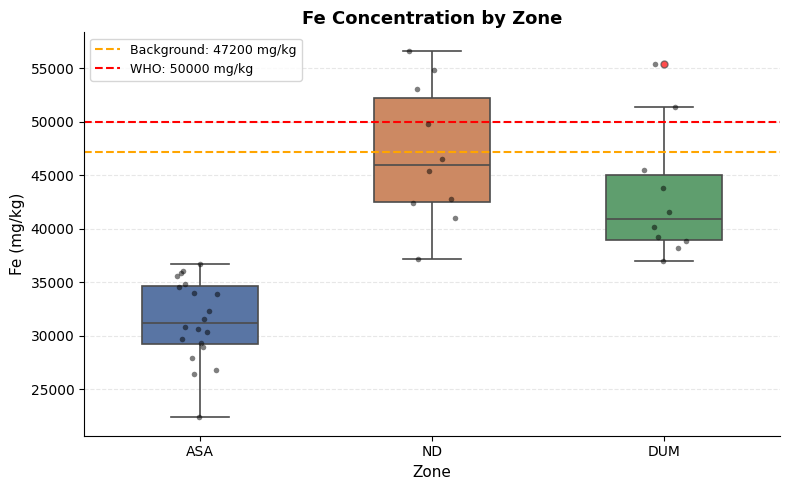

✅ Saved: boxplot_Fe.svg


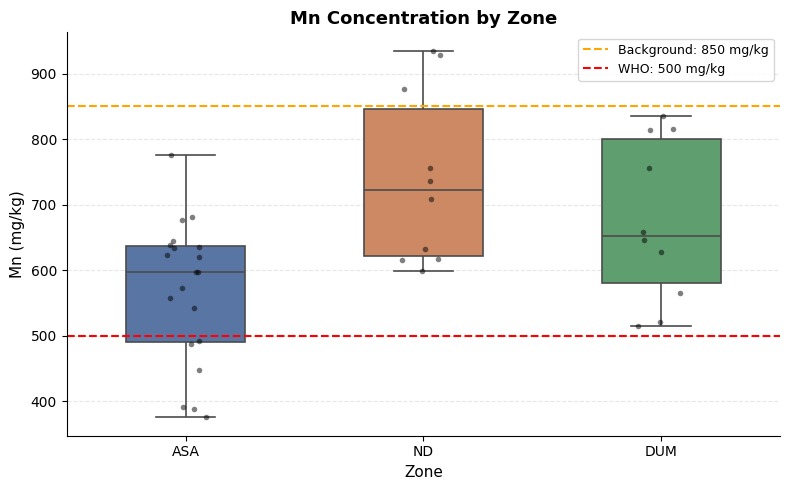

✅ Saved: boxplot_Mn.svg


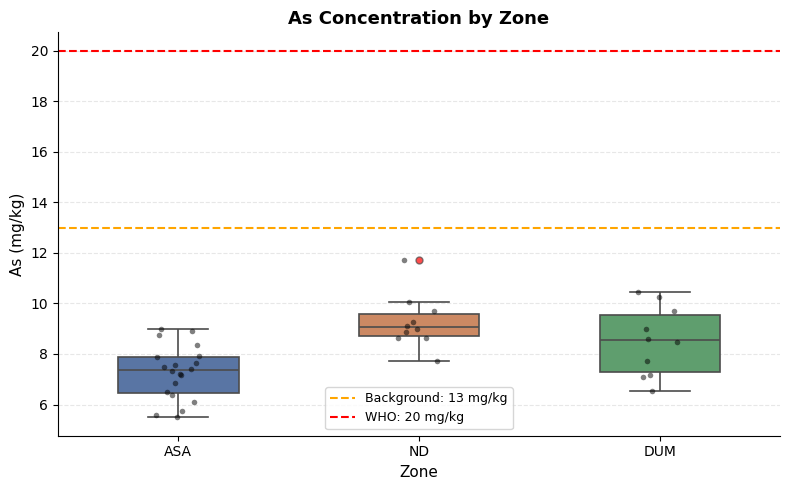

✅ Saved: boxplot_As.svg


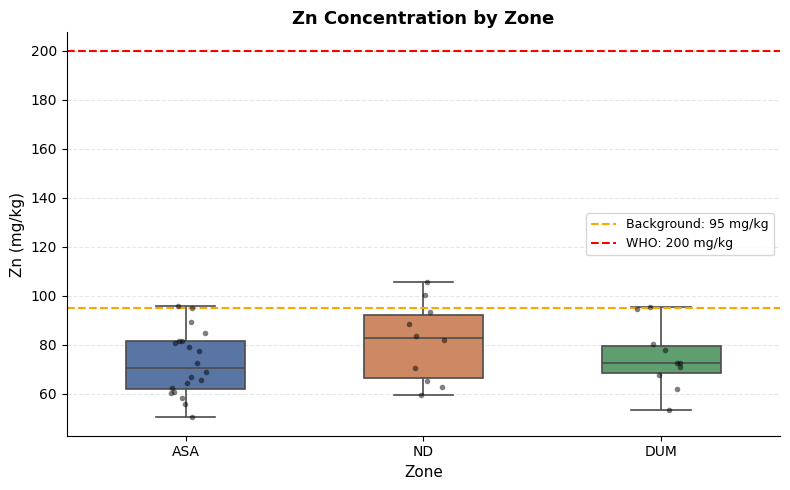

✅ Saved: boxplot_Zn.svg


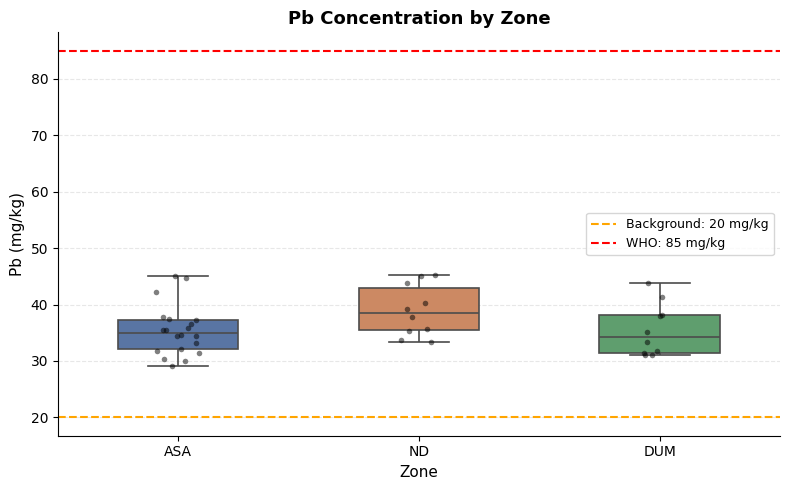

✅ Saved: boxplot_Pb.svg


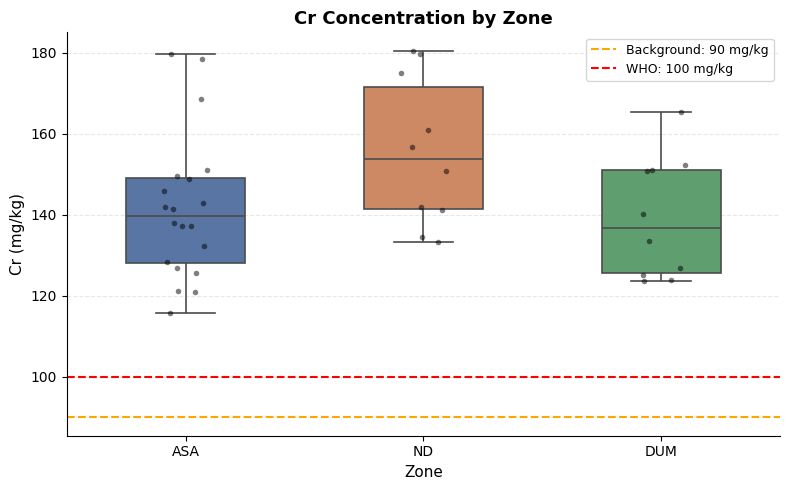

✅ Saved: boxplot_Cr.svg


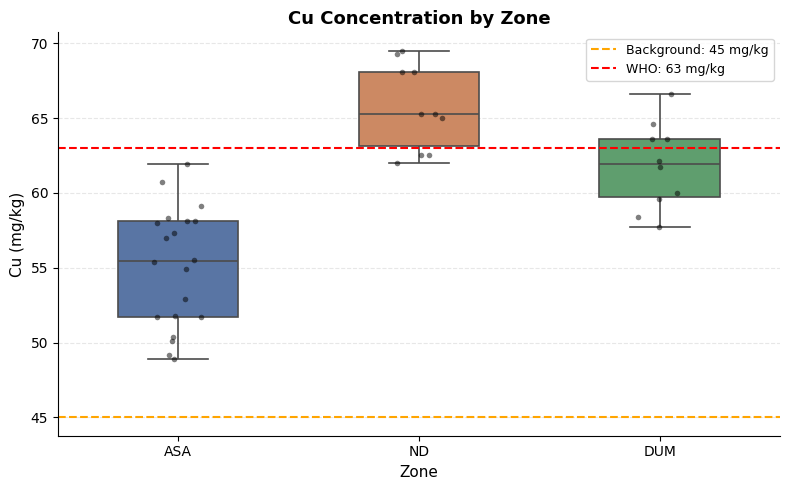

✅ Saved: boxplot_Cu.svg


In [8]:
# ── CELL 8 (FIXED): Boxplot by zone — seaborn FutureWarning resolved ──────────
# FIX: use hue= + legend=False instead of palette= without hue
import seaborn as sns

zone_palette = {'ASA': '#4C72B0', 'ND': '#DD8452', 'DUM': '#55A868'}

for m in metals:
    fig, ax = plt.subplots(figsize=(8, 5))

    # ✅ FIXED: hue='Zone' + legend=False (no FutureWarning)
    sns.boxplot(data=df, x='Zone', y=m, hue='Zone',
                palette=zone_palette, width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markerfacecolor='red',
                                markersize=5, alpha=0.7),
                legend=False, ax=ax)
    sns.stripplot(data=df, x='Zone', y=m, color='black',
                  size=4, alpha=0.5, jitter=True, ax=ax)

    ax.axhline(background[m],    color='orange', lw=1.5, ls='--',
               label=f'Background: {background[m]} mg/kg')
    ax.axhline(who_guideline[m], color='red',    lw=1.5, ls='--',
               label=f'WHO: {who_guideline[m]} mg/kg')

    ax.set_title(f'{m} Concentration by Zone', fontsize=13, fontweight='bold')
    ax.set_xlabel('Zone', fontsize=11)
    ax.set_ylabel(f'{m} (mg/kg)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'boxplot_{m}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: boxplot_{m}.svg')

In [9]:
# ── CELL 9: Contamination Factor (CF) ────────────────────────────────────────
def cf_class(v):
    if v < 1:   return 'Low'
    elif v < 3: return 'Moderate'
    elif v < 6: return 'Considerable'
    else:       return 'Very High'

cf_df = df[['Sample','Zone']].copy()
for m in metals:
    cf_df[f'CF_{m}'] = (df[m] / background[m]).round(3)
    cf_df[f'CF_{m}_class'] = cf_df[f'CF_{m}'].apply(cf_class)

print('✅ Contamination Factor (CF):')
for m in metals:
    mean_cf = cf_df[f'CF_{m}'].mean()
    print(f'   {m:4s}: Mean CF = {mean_cf:.3f} → {cf_class(mean_cf)}')

cf_df.to_excel('contamination_factor.xlsx', index=False)
print('\n✅ Saved: contamination_factor.xlsx')

✅ Contamination Factor (CF):
   Ni  : Mean CF = 0.618 → Low
   V   : Mean CF = 0.603 → Low
   Co  : Mean CF = 3.103 → Considerable
   Cd  : Mean CF = 4.296 → Considerable
   Fe  : Mean CF = 0.810 → Low
   Mn  : Mean CF = 0.751 → Low
   As  : Mean CF = 0.621 → Low
   Zn  : Mean CF = 0.793 → Low
   Pb  : Mean CF = 1.818 → Moderate
   Cr  : Mean CF = 1.606 → Moderate
   Cu  : Mean CF = 1.320 → Moderate

✅ Saved: contamination_factor.xlsx


In [10]:
# ── CELL 10: Geo-accumulation Index (Igeo) ────────────────────────────────────
def igeo_class(v):
    if v <= 0:   return 'Practically Uncontaminated'
    elif v <= 1: return 'Uncontaminated to Moderate'
    elif v <= 2: return 'Moderately Contaminated'
    elif v <= 3: return 'Moderate to Heavy'
    elif v <= 4: return 'Heavily Contaminated'
    elif v <= 5: return 'Heavy to Extreme'
    else:        return 'Extremely Contaminated'

igeo_df = df[['Sample','Zone']].copy()
for m in metals:
    igeo_df[f'Igeo_{m}'] = np.log2(df[m] / (1.5 * background[m])).round(3)
    igeo_df[f'Igeo_{m}_class'] = igeo_df[f'Igeo_{m}'].apply(igeo_class)

print('✅ Geo-accumulation Index (Igeo):')
for m in metals:
    mean_igeo = igeo_df[f'Igeo_{m}'].mean()
    print(f'   {m:4s}: Mean Igeo = {mean_igeo:.3f} → {igeo_class(mean_igeo)}')

igeo_df.to_excel('geoaccumulation_index.xlsx', index=False)
print('\n✅ Saved: geoaccumulation_index.xlsx')

✅ Geo-accumulation Index (Igeo):
   Ni  : Mean Igeo = -1.293 → Practically Uncontaminated
   V   : Mean Igeo = -1.327 → Practically Uncontaminated
   Co  : Mean Igeo = 1.041 → Moderately Contaminated
   Cd  : Mean Igeo = 1.142 → Moderately Contaminated
   Fe  : Mean Igeo = -0.924 → Practically Uncontaminated
   Mn  : Mean Igeo = -1.032 → Practically Uncontaminated
   As  : Mean Igeo = -1.294 → Practically Uncontaminated
   Zn  : Mean Igeo = -0.945 → Practically Uncontaminated
   Pb  : Mean Igeo = 0.266 → Uncontaminated to Moderate
   Cr  : Mean Igeo = 0.087 → Uncontaminated to Moderate
   Cu  : Mean Igeo = -0.191 → Practically Uncontaminated

✅ Saved: geoaccumulation_index.xlsx


In [11]:
# ── CELL 11: Enrichment Factor (EF) ──────────────────────────────────────────
def ef_class(v):
    if v < 2:    return 'Minimal'
    elif v < 5:  return 'Moderate'
    elif v < 20: return 'Significant'
    elif v < 40: return 'Very High'
    else:        return 'Extremely High'

ef_metals = [m for m in metals if m != 'Fe']
ef_df = df[['Sample','Zone']].copy()
for m in ef_metals:
    ef_df[f'EF_{m}'] = (
        (df[m] / df['Fe']) / (background[m] / background['Fe'])
    ).round(3)
    ef_df[f'EF_{m}_class'] = ef_df[f'EF_{m}'].apply(ef_class)

print('✅ Enrichment Factor (EF) — Fe as reference:')
for m in ef_metals:
    mean_ef = ef_df[f'EF_{m}'].mean()
    print(f'   {m:4s}: Mean EF = {mean_ef:.3f} → {ef_class(mean_ef)}')

ef_df.to_excel('enrichment_factor.xlsx', index=False)
print('\n✅ Saved: enrichment_factor.xlsx')

✅ Enrichment Factor (EF) — Fe as reference:
   Ni  : Mean EF = 0.779 → Minimal
   V   : Mean EF = 0.765 → Minimal
   Co  : Mean EF = 3.946 → Moderate
   Cd  : Mean EF = 5.365 → Significant
   Mn  : Mean EF = 0.938 → Minimal
   As  : Mean EF = 0.782 → Minimal
   Zn  : Mean EF = 1.005 → Minimal
   Pb  : Mean EF = 2.343 → Moderate
   Cr  : Mean EF = 2.070 → Moderate
   Cu  : Mean EF = 1.682 → Minimal

✅ Saved: enrichment_factor.xlsx


In [12]:
# ── CELL 12: Pollution Load Index (PLI) ───────────────────────────────────────
pli_df = df[['Sample','Zone']].copy()
cf_vals = pd.DataFrame({m: df[m] / background[m] for m in metals})
pli_df['PLI'] = (cf_vals.prod(axis=1) ** (1/len(metals))).round(3)
pli_df['PLI_class'] = pli_df['PLI'].apply(
    lambda x: 'No Pollution' if x < 1 else 'Polluted'
)

print('✅ Pollution Load Index (PLI):')
print(f'   Mean : {pli_df["PLI"].mean():.3f}')
print(f'   Min  : {pli_df["PLI"].min():.3f}')
print(f'   Max  : {pli_df["PLI"].max():.3f}')
print(f'   Polluted samples: {(pli_df["PLI"] >= 1).sum()} / {len(pli_df)}')

pli_df.to_excel('pollution_load_index.xlsx', index=False)
print('\n✅ Saved: pollution_load_index.xlsx')

✅ Pollution Load Index (PLI):
   Mean : 1.144
   Min  : 0.752
   Max  : 1.395
   Polluted samples: 32 / 40

✅ Saved: pollution_load_index.xlsx


In [13]:
# ── CELL 13: Health risk parameters (Table 3.2 & 3.3) ────────────────────────
params = {
    'EF'    : {'Adults': 365,    'Children': 365},
    'ED'    : {'Adults': 24,     'Children': 6},
    'BW'    : {'Adults': 70,     'Children': 20},
    'AT_nc' : {'Adults': 24*365, 'Children': 6*365},   # non-cancer AT (days)
    'AT_c'  : {'Adults': 70*365, 'Children': 70*365},  # cancer AT (days)
    'IR_ing': {'Adults': 100,    'Children': 200},      # mg/day
    'IR_inh': {'Adults': 12.8,   'Children': 7.63},    # m3/day
    'PEF'   : 1.36e9,                                   # m3/kg
    'ESA'   : {'Adults': 4350,   'Children': 1600},    # cm2
    'SAF'   : {'Adults': 0.7,    'Children': 0.2},     # mg/cm2
    'DAF'   : 0.001,                                    # dimensionless
    'CF'    : 1e-6,                                     # kg/mg unit conversion ← CRITICAL
}

RfD = {
    'Ni': {'Ingestion': 0.02,   'Inhalation': 0.0002,  'Dermal': 0.0054},
    'V' : {'Ingestion': 0.001,  'Inhalation': 0.0001,  'Dermal': 0.00009},
    'Co': {'Ingestion': 0.03,   'Inhalation': 5.00e-5, 'Dermal': 8.1e-5},
    'Cd': {'Ingestion': 0.0005, 'Inhalation': 1.00e-5, 'Dermal': 2.5e-5},
    'Fe': {'Ingestion': 0.7,    'Inhalation': 0.7,     'Dermal': 0.07},
    'Mn': {'Ingestion': 0.024,  'Inhalation': 0.05,    'Dermal': 0.0056},
    'As': {'Ingestion': 0.0003, 'Inhalation': 0.00003, 'Dermal': 0.00012},
    'Zn': {'Ingestion': 0.3,    'Inhalation': 0.01,    'Dermal': 0.06},
    'Pb': {'Ingestion': 0.0014, 'Inhalation': 0.0001,  'Dermal': None},
    'Cr': {'Ingestion': 0.003,  'Inhalation': 0.0001,  'Dermal': 0.0003},
    'Cu': {'Ingestion': 0.04,   'Inhalation': 0.01,    'Dermal': 0.02},
}

CSF = {
    'Ni': {'Ingestion': 0.91,   'Inhalation': 0.91,  'Dermal': 4.55},
    'As': {'Ingestion': 1.5,    'Inhalation': 12.0,  'Dermal': 47.5},
    'Pb': {'Ingestion': 0.0085, 'Inhalation': 0.042, 'Dermal': 0.425},
    'Cr': {'Ingestion': 0.42,   'Inhalation': 510.0, 'Dermal': 2.1},
}

print('✅ Health risk parameters loaded')
print(f'   CF (conversion factor) = {params["CF"]}  ← This was missing in the old code!')
print(f'   AT_nc Adults = {params["AT_nc"]["Adults"]} days')
print(f'   AT_c  Adults = {params["AT_c"]["Adults"]} days')
print(f'   Carcinogenic metals: {list(CSF.keys())}')

✅ Health risk parameters loaded
   CF (conversion factor) = 1e-06  ← This was missing in the old code!
   AT_nc Adults = 8760 days
   AT_c  Adults = 25550 days
   Carcinogenic metals: ['Ni', 'As', 'Pb', 'Cr']


In [14]:
# ── CELL 14 (FIXED): Average Daily Dose (ADD) ─────────────────────────────────
#
# ❌ OLD (wrong):
#   ADD_ing = (C * IR * EF * ED) / (BW * AT)
#   ADD_der = (C * ESA * SAF * DAF * EF * ED) / (BW * AT)
#
# ✅ FIXED (correct USEPA formula):
#   ADD_ing = (C * IR * EF * ED * CF) / (BW * AT)    ← CF = 1e-6 converts mg→kg
#   ADD_der = (C * ESA * SAF * DAF * CF * EF * ED) / (BW * AT)
#   ADD_inh = (C * IR_inh * EF * ED) / (PEF * BW * AT)  ← PEF handles units here
#
# Units check for ADD_ing:
#   C[mg/kg] × IR[mg/day] × CF[kg/mg] × EF[day/yr] × ED[yr]
#   ─────────────────────────────────────────────────────────── = mg/kg/day  ✓
#            BW[kg] × AT[days]

add_rows = []
CF = params['CF']  # 1e-6 kg/mg

for _, row in df.iterrows():
    for pop in ['Adults', 'Children']:
        rec = {'Sample': row['Sample'], 'Zone': row['Zone'], 'Population': pop}
        EF   = params['EF'][pop]
        ED   = params['ED'][pop]
        BW   = params['BW'][pop]
        AT   = params['AT_nc'][pop]
        IR_ing = params['IR_ing'][pop]
        IR_inh = params['IR_inh'][pop]
        ESA    = params['ESA'][pop]
        SAF    = params['SAF'][pop]
        DAF    = params['DAF']
        PEF    = params['PEF']

        for m in metals:
            C = row[m]
            # ✅ CF = 1e-6 applied to ingestion and dermal
            rec[f'{m}_ADD_ing'] = (C * IR_ing * CF * EF * ED) / (BW * AT)
            rec[f'{m}_ADD_inh'] = (C * IR_inh * EF * ED) / (PEF * BW * AT)
            rec[f'{m}_ADD_der'] = (C * ESA * SAF * DAF * CF * EF * ED) / (BW * AT)
        add_rows.append(rec)

add_df = pd.DataFrame(add_rows)
add_df.to_excel('exposure_doses_ADD.xlsx', index=False)

# Sanity check — print a few representative ADD values
print('✅ ADD computed (sample check for Fe, Adults):')
fe_ing_sample = add_df[add_df['Population']=='Adults']['Fe_ADD_ing'].mean()
print(f'   Mean ADD_ing Fe (Adults) = {fe_ing_sample:.4e} mg/kg/day')
print(f'   Expected order of magnitude: ~1e-5 to 1e-4  ← if >1 something is wrong')
print(f'\n✅ Saved: exposure_doses_ADD.xlsx')

✅ ADD computed (sample check for Fe, Adults):
   Mean ADD_ing Fe (Adults) = 5.4633e-02 mg/kg/day
   Expected order of magnitude: ~1e-5 to 1e-4  ← if >1 something is wrong

✅ Saved: exposure_doses_ADD.xlsx


In [15]:
# ── CELL 15: Non-carcinogenic risk — HQ and HI ───────────────────────────────
# This cell is correct once Cell 14 is fixed.
# HQ = ADD / RfD    |    HI = ΣHQ (all metals, all pathways)
# HI > 1 = potential non-carcinogenic risk

hq_rows = []
for _, row in add_df.iterrows():
    rec = {'Sample': row['Sample'], 'Zone': row['Zone'],
           'Population': row['Population']}
    hi = 0
    for m in metals:
        HQ_ing = row[f'{m}_ADD_ing'] / RfD[m]['Ingestion']
        HQ_inh = row[f'{m}_ADD_inh'] / RfD[m]['Inhalation']
        HQ_der = (row[f'{m}_ADD_der'] / RfD[m]['Dermal']
                  if RfD[m]['Dermal'] is not None else 0.0)
        HQ_tot = HQ_ing + HQ_inh + HQ_der
        hi += HQ_tot
        rec[f'{m}_HQ_ing']   = round(HQ_ing, 6)
        rec[f'{m}_HQ_inh']   = round(HQ_inh, 8)
        rec[f'{m}_HQ_der']   = round(HQ_der, 6)
        rec[f'{m}_HQ_total'] = round(HQ_tot, 6)
    rec['HI'] = round(hi, 6)
    hq_rows.append(rec)

hq_df = pd.DataFrame(hq_rows)

print('✅ HQ and HI computed')
for pop in ['Adults', 'Children']:
    sub = hq_df[hq_df['Population'] == pop]
    print(f'\n  {pop}:')
    print(f'    Mean HI : {sub["HI"].mean():.4f}')
    print(f'    Max HI  : {sub["HI"].max():.4f}')
    print(f'    HI > 1  : {(sub["HI"] > 1).sum()} / {len(sub)} samples')
    print(f'    [HI > 1 indicates potential non-carcinogenic risk]')

hq_df.to_excel('hazard_quotient_HQ_HI.xlsx', index=False)
print('\n✅ Saved: hazard_quotient_HQ_HI.xlsx')

✅ HQ and HI computed

  Adults:
    Mean HI : 0.5099
    Max HI  : 0.6140
    HI > 1  : 0 / 40 samples
    [HI > 1 indicates potential non-carcinogenic risk]

  Children:
    Mean HI : 2.7379
    Max HI  : 3.3174
    HI > 1  : 40 / 40 samples
    [HI > 1 indicates potential non-carcinogenic risk]

✅ Saved: hazard_quotient_HQ_HI.xlsx


In [16]:
# ── CELL 16 (FIXED): Carcinogenic Risk (CR) ───────────────────────────────────
#
# ❌ OLD — missing CF=1e-6 in LADD_ing and LADD_der → CR was ~68 (impossible!)
# ✅ FIXED — CF=1e-6 included → CR in realistic range 1e-6 to 1e-3
#
# CR = LADD × CSF
# LADD uses AT_c = 70×365 days (lifetime average)
# Acceptable: <1e-6 | Tolerable: 1e-6 to 1e-4 | Unacceptable: >1e-4

def cr_level(v):
    if v < 1e-6:   return 'Acceptable'
    elif v < 1e-4: return 'Tolerable'
    else:          return 'Unacceptable'

carc_metals = list(CSF.keys())
CF = params['CF']   # 1e-6 kg/mg
cr_rows = []

for _, row in df.iterrows():
    for pop in ['Adults', 'Children']:
        rec = {'Sample': row['Sample'], 'Zone': row['Zone'], 'Population': pop}
        EF   = params['EF'][pop]
        ED   = params['ED'][pop]
        BW   = params['BW'][pop]
        AT   = params['AT_c'][pop]   # lifetime AT for cancer
        IR_ing = params['IR_ing'][pop]
        IR_inh = params['IR_inh'][pop]
        ESA  = params['ESA'][pop]
        SAF  = params['SAF'][pop]
        DAF  = params['DAF']
        PEF  = params['PEF']

        total_cr = 0
        for m in carc_metals:
            C = row[m]
            # ✅ CF = 1e-6 applied to ingestion and dermal LADD
            LADD_ing = (C * IR_ing * CF * EF * ED) / (BW * AT)
            LADD_inh = (C * IR_inh * EF * ED) / (PEF * BW * AT)
            LADD_der = (C * ESA * SAF * DAF * CF * EF * ED) / (BW * AT)

            CR_ing = LADD_ing * CSF[m]['Ingestion']
            CR_inh = LADD_inh * CSF[m]['Inhalation']
            CR_der = LADD_der * CSF[m]['Dermal']
            CR_tot = CR_ing + CR_inh + CR_der
            total_cr += CR_tot

            rec[f'{m}_LADD_ing'] = LADD_ing
            rec[f'{m}_LADD_inh'] = LADD_inh
            rec[f'{m}_LADD_der'] = LADD_der
            rec[f'{m}_CR_ing']   = CR_ing
            rec[f'{m}_CR_inh']   = CR_inh
            rec[f'{m}_CR_der']   = CR_der
            rec[f'{m}_CR_total'] = CR_tot

        rec['Total_CR'] = total_cr
        rec['CR_level'] = cr_level(total_cr)
        cr_rows.append(rec)

cr_df = pd.DataFrame(cr_rows)

print('✅ Carcinogenic Risk (CR) computed')
for pop in ['Adults', 'Children']:
    sub = cr_df[cr_df['Population'] == pop]
    print(f'\n  {pop}:')
    print(f'    Mean Total CR  : {sub["Total_CR"].mean():.3e}')
    print(f'    Max Total CR   : {sub["Total_CR"].max():.3e}')
    print(f'    Unacceptable (>1e-4): {(sub["Total_CR"] > 1e-4).sum()} samples')
    print(f'    Tolerable (1e-6–1e-4): {((sub["Total_CR"] >= 1e-6) & (sub["Total_CR"] < 1e-4)).sum()} samples')
    print(f'    Acceptable (<1e-6)  : {(sub["Total_CR"] < 1e-6).sum()} samples')

    # Per-metal breakdown
    print(f'\n  Per-metal CR mean ({pop}):')
    for m in carc_metals:
        print(f'    {m:4s}: {sub[f"{m}_CR_total"].mean():.3e}')

cr_df.to_excel('carcinogenic_risk_CR.xlsx', index=False)
print('\n✅ Saved: carcinogenic_risk_CR.xlsx')

✅ Carcinogenic Risk (CR) computed

  Adults:
    Mean Total CR  : 7.128e-05
    Max Total CR   : 8.661e-05
    Unacceptable (>1e-4): 0 samples
    Tolerable (1e-6–1e-4): 40 samples
    Acceptable (<1e-6)  : 0 samples

  Per-metal CR mean (Adults):
    Ni  : 2.160e-05
    As  : 1.165e-05
    Pb  : 3.819e-07
    Cr  : 3.765e-05

  Children:
    Mean Total CR  : 9.846e-05
    Max Total CR   : 1.200e-04
    Unacceptable (>1e-4): 16 samples
    Tolerable (1e-6–1e-4): 24 samples
    Acceptable (<1e-6)  : 0 samples

  Per-metal CR mean (Children):
    Ni  : 3.306e-05
    As  : 1.091e-05
    Pb  : 2.861e-07
    Cr  : 5.421e-05

✅ Saved: carcinogenic_risk_CR.xlsx


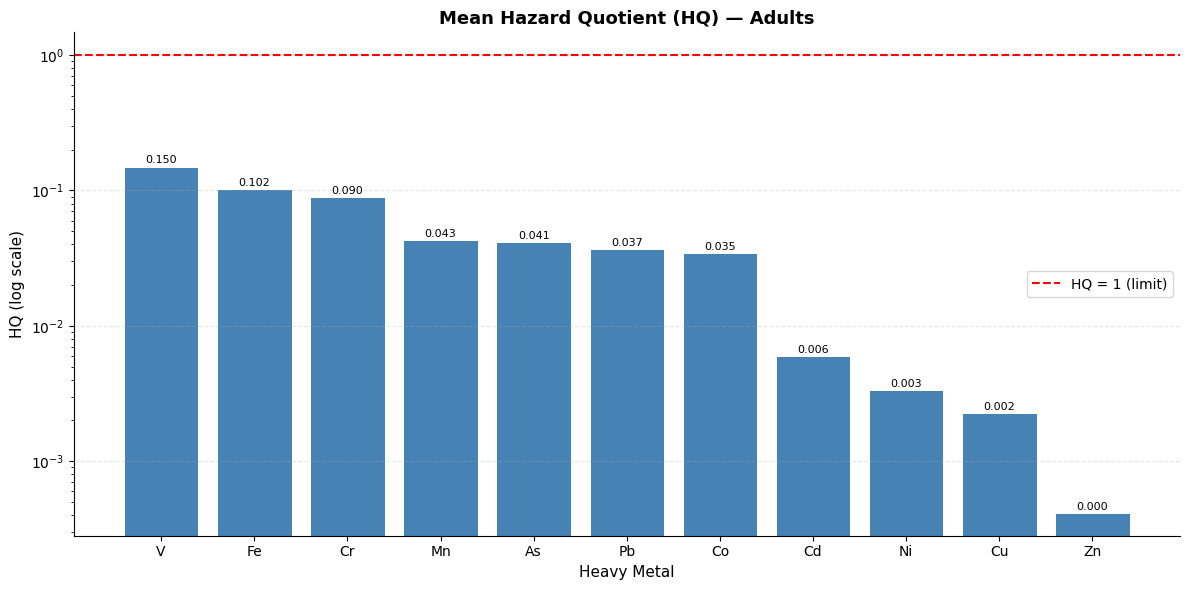

✅ Saved: HQ_bar_Adults.svg


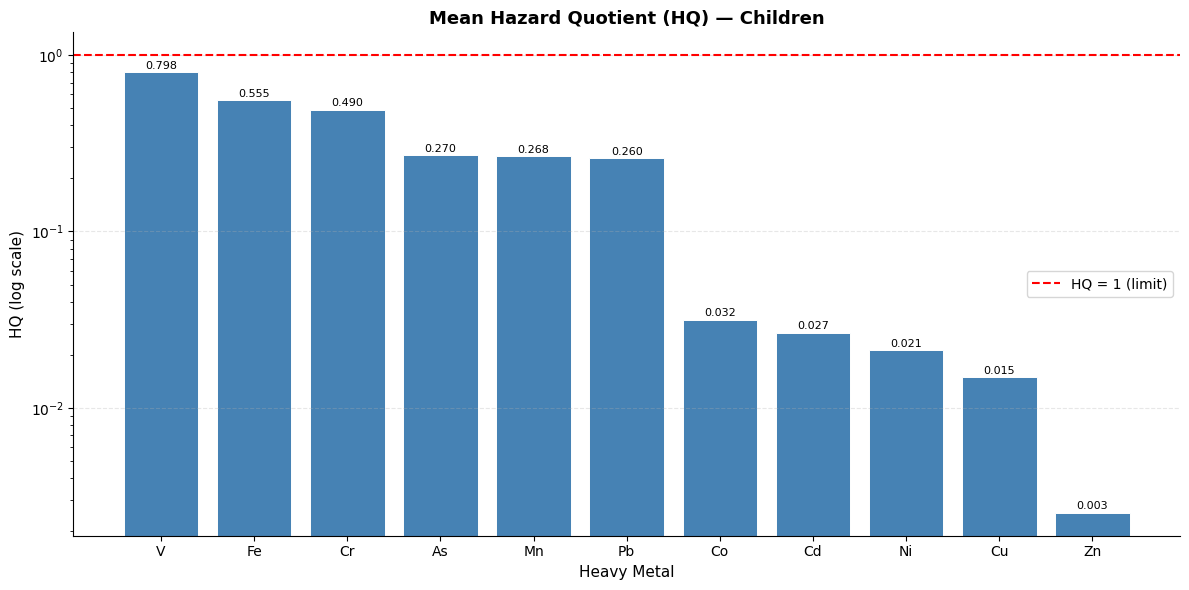

✅ Saved: HQ_bar_Children.svg


In [17]:
# ── CELL 17: HQ bar chart per metal per population ───────────────────────────
for pop in ['Adults', 'Children']:
    sub = hq_df[hq_df['Population'] == pop]
    mean_hq = {m: sub[f'{m}_HQ_total'].mean() for m in metals}
    sorted_m = sorted(mean_hq, key=mean_hq.get, reverse=True)
    colors = ['firebrick' if mean_hq[m] > 1 else 'steelblue' for m in sorted_m]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(sorted_m, [mean_hq[m] for m in sorted_m],
                  color=colors, edgecolor='white', linewidth=0.7)
    ax.axhline(1, color='red', linewidth=1.5, linestyle='--', label='HQ = 1 (limit)')

    for bar, m in zip(bars, sorted_m):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{mean_hq[m]:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'Mean Hazard Quotient (HQ) — {pop}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Heavy Metal', fontsize=11)
    ax.set_ylabel('HQ (log scale)', fontsize=11)
    ax.set_yscale('log')  # log scale needed — values span orders of magnitude
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'HQ_bar_{pop}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: HQ_bar_{pop}.svg')

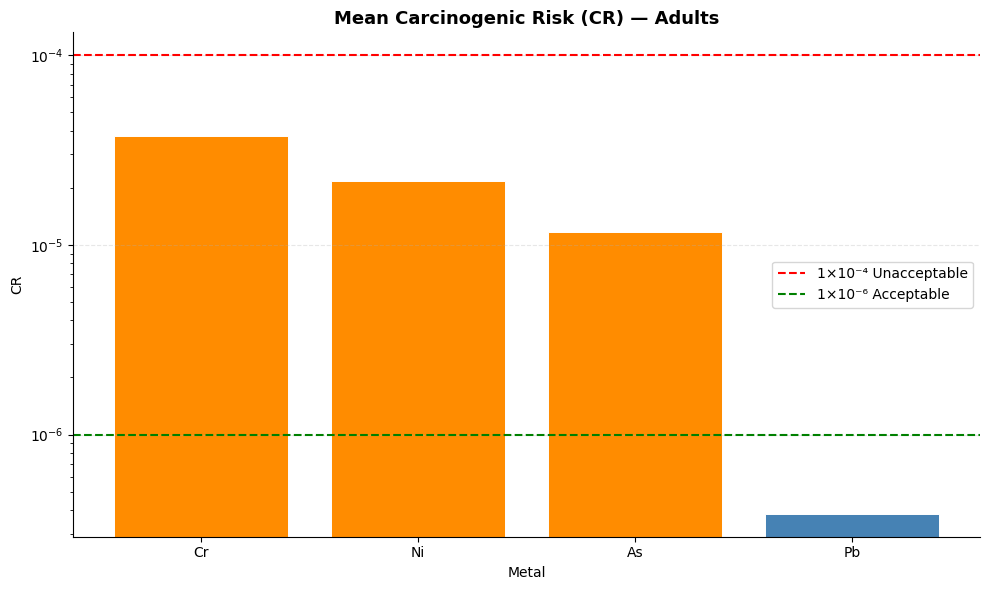

✅ Saved: CR_bar_Adults.svg


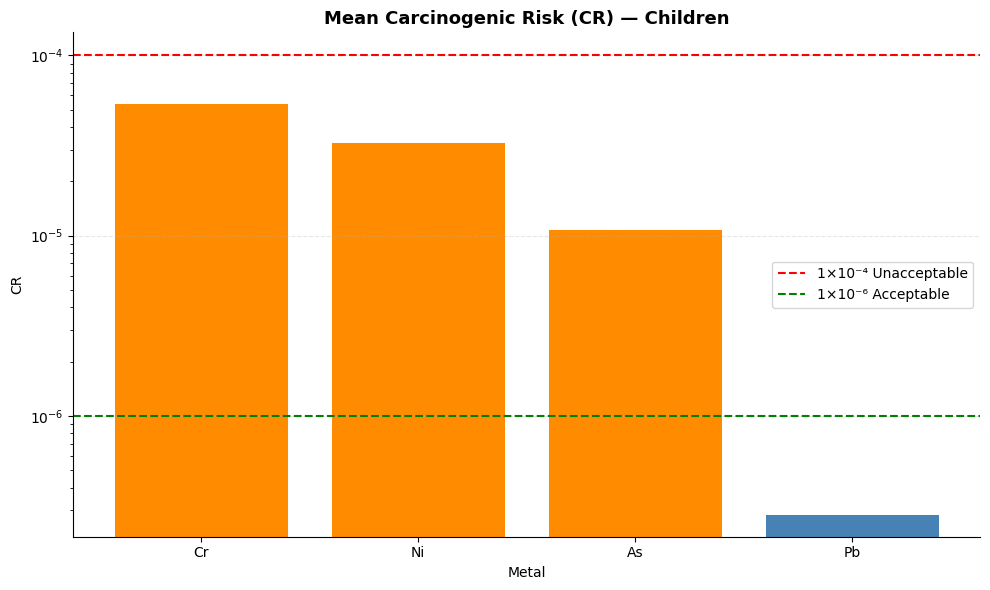

✅ Saved: CR_bar_Children.svg


In [18]:
# ── CELL 18: CR bar chart per carcinogenic metal ─────────────────────────────
for pop in ['Adults', 'Children']:
    sub = cr_df[cr_df['Population'] == pop]
    mean_cr = {m: sub[f'{m}_CR_total'].mean() for m in carc_metals}
    sorted_m = sorted(mean_cr, key=mean_cr.get, reverse=True)

    def bar_color(v):
        if v > 1e-4:  return 'firebrick'
        elif v > 1e-6: return 'darkorange'
        return 'steelblue'

    colors = [bar_color(mean_cr[m]) for m in sorted_m]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(sorted_m, [mean_cr[m] for m in sorted_m],
           color=colors, edgecolor='white', linewidth=0.7)
    ax.axhline(1e-4, color='red',    lw=1.5, ls='--', label='1×10⁻⁴ Unacceptable')
    ax.axhline(1e-6, color='green',  lw=1.5, ls='--', label='1×10⁻⁶ Acceptable')
    ax.set_yscale('log')
    ax.set_title(f'Mean Carcinogenic Risk (CR) — {pop}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Metal'); ax.set_ylabel('CR')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'CR_bar_{pop}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: CR_bar_{pop}.svg')

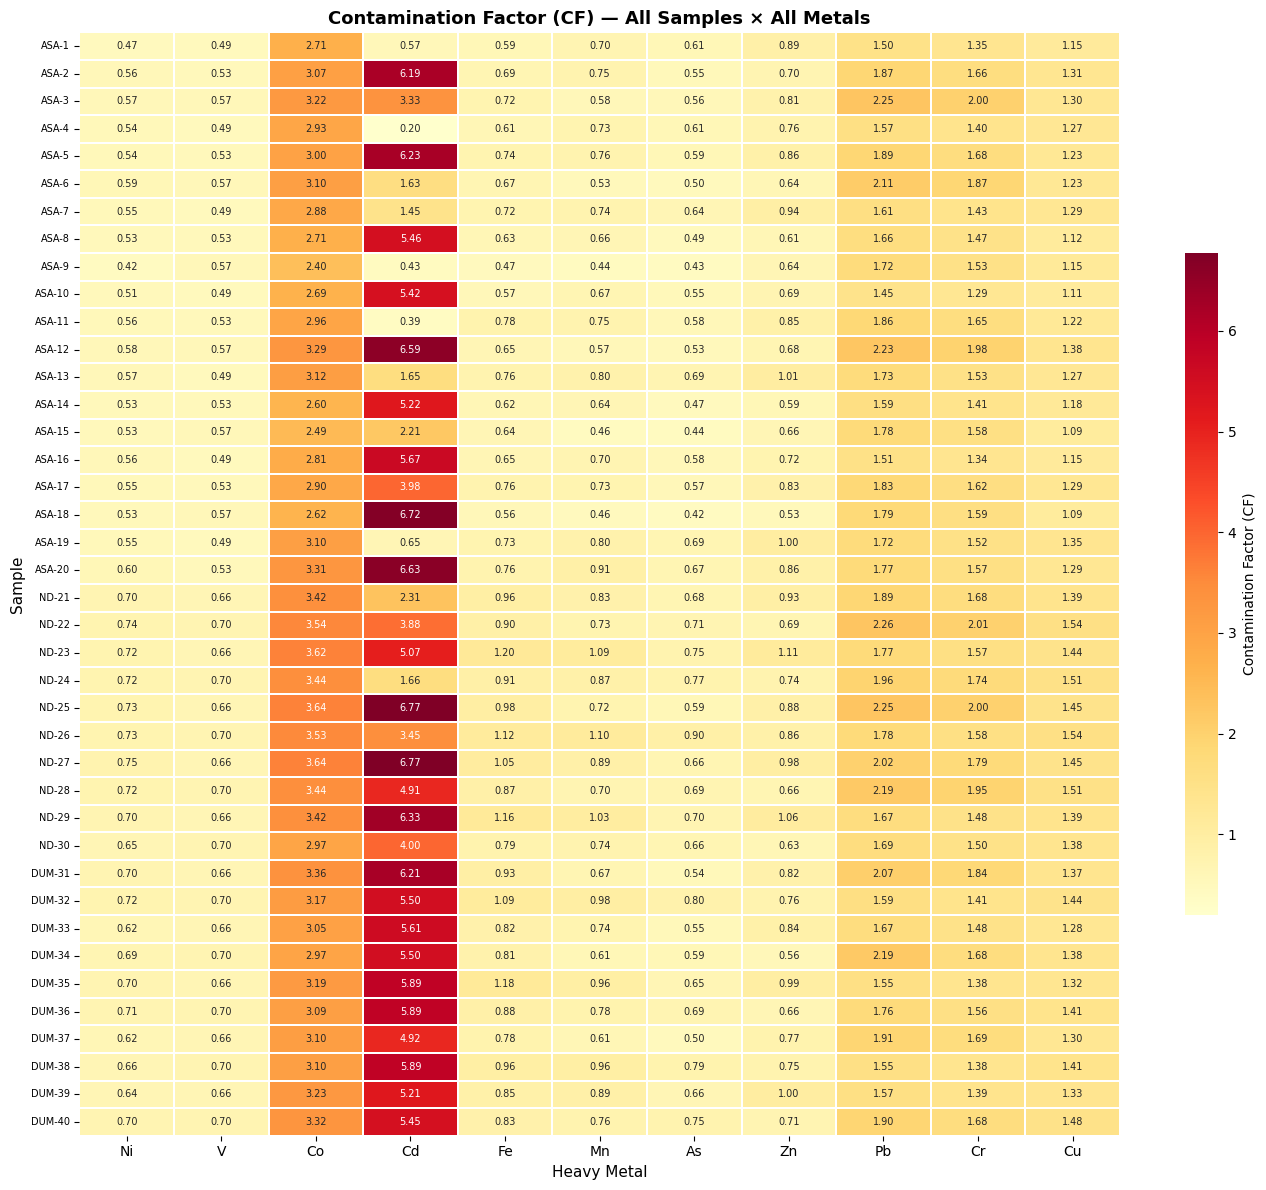

✅ Saved: heatmap_CF.svg


In [19]:
# ── CELL 19: CF heatmap all samples × all metals ─────────────────────────────
cf_pivot = cf_df[['Sample'] + [f'CF_{m}' for m in metals]].set_index('Sample')
cf_pivot.columns = metals

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cf_pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'label': 'Contamination Factor (CF)', 'shrink': 0.6}, ax=ax)
ax.set_title('Contamination Factor (CF) — All Samples × All Metals',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Heavy Metal', fontsize=11)
ax.set_ylabel('Sample', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig('heatmap_CF.svg', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: heatmap_CF.svg')

In [20]:
# ── CELL 20: Output file checklist ───────────────────────────────────────────
import os

expected_files = [
    'descriptive_statistics.xlsx',
    'contamination_factor.xlsx',
    'geoaccumulation_index.xlsx',
    'enrichment_factor.xlsx',
    'pollution_load_index.xlsx',
    'exposure_doses_ADD.xlsx',
    'hazard_quotient_HQ_HI.xlsx',
    'carcinogenic_risk_CR.xlsx',
    'heatmap_CF.svg',
] + [f'distribution_{m}.svg'     for m in metals] \
  + [f'distribution_log_{m}.svg' for m in metals] \
  + [f'boxplot_{m}.svg'          for m in metals] \
  + [f'HQ_bar_{pop}.svg'         for pop in ['Adults','Children']] \
  + [f'CR_bar_{pop}.svg'         for pop in ['Adults','Children']]

print('\n📁 Output files checklist:')
print('═'*60)
for f in expected_files:
    status = '✅' if os.path.exists(f) else '⚠️  MISSING'
    print(f'  {status}  {f}')
print('═'*60)
print(f'\n  Total expected : {len(expected_files)}')
print(f'  Found          : {sum(os.path.exists(f) for f in expected_files)}')


📁 Output files checklist:
════════════════════════════════════════════════════════════
  ✅  descriptive_statistics.xlsx
  ✅  contamination_factor.xlsx
  ✅  geoaccumulation_index.xlsx
  ✅  enrichment_factor.xlsx
  ✅  pollution_load_index.xlsx
  ✅  exposure_doses_ADD.xlsx
  ✅  hazard_quotient_HQ_HI.xlsx
  ✅  carcinogenic_risk_CR.xlsx
  ✅  heatmap_CF.svg
  ✅  distribution_Ni.svg
  ✅  distribution_V.svg
  ✅  distribution_Co.svg
  ✅  distribution_Cd.svg
  ✅  distribution_Fe.svg
  ✅  distribution_Mn.svg
  ✅  distribution_As.svg
  ✅  distribution_Zn.svg
  ✅  distribution_Pb.svg
  ✅  distribution_Cr.svg
  ✅  distribution_Cu.svg
  ✅  distribution_log_Ni.svg
  ✅  distribution_log_V.svg
  ✅  distribution_log_Co.svg
  ✅  distribution_log_Cd.svg
  ✅  distribution_log_Fe.svg
  ✅  distribution_log_Mn.svg
  ✅  distribution_log_As.svg
  ✅  distribution_log_Zn.svg
  ✅  distribution_log_Pb.svg
  ✅  distribution_log_Cr.svg
  ✅  distribution_log_Cu.svg
  ✅  boxplot_Ni.svg
  ✅  boxplot_V.svg
  ✅  boxplot_C